In [149]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro

In [111]:
dfSES = pd.read_csv("dfCOG.csv", usecols=["CNTRYID", "ses_all_mean"])
dfSES.describe()

,CNTRYID,ses_all_mean
count,81.000000,80.000000
mean,430.049383,-0.357625
std,245.127105,0.583400
min,8.000000,-2.010000
25%,222.000000,-0.735000
50%,400.000000,-0.245000
75%,620.000000,0.087500
max,901.000000,0.520000


In [113]:
ses_mean_mean = dfSES["ses_all_mean"].mean()
ses_sd = dfSES["ses_all_mean"].std()

In [115]:
dfSES["normalized_ses_all_mean"] = (dfSES["ses_all_mean"] - ses_mean_mean)/(ses_sd)
dfSES.head()

,CNTRYID,ses_all_mean,normalized_ses_all_mean
0,100,-0.27,0.150197
1,116,-2.01,-2.832321
2,124,0.38,1.264356
3,152,-0.51,-0.261185
4,158,-0.19,0.287325


In [117]:
min = dfSES["ses_all_mean"].min()*(-1)
dfSES["shift"] = dfSES["ses_all_mean"] + min
dfSES["shift"] = np.sqrt(dfSES["shift"])
dfSES.rename(columns = {"shift" : "shift_and_log"}, inplace=True)
dfSES.describe()

,CNTRYID,ses_all_mean,normalized_ses_all_mean,shift_and_log
count,81.000000,80.000000,8.000000e+01,80.000000
mean,430.049383,-0.357625,-4.163336e-17,1.255307
std,245.127105,0.583400,1.000000e+00,0.278474
min,8.000000,-2.010000,-2.832321e+00,0.000000
25%,222.000000,-0.735000,-6.468551e-01,1.129152
50%,400.000000,-0.245000,1.930495e-01,1.328521
75%,620.000000,0.087500,7.629848e-01,1.448268
max,901.000000,0.520000,1.504329e+00,1.590597


In [119]:
shift_mean = dfSES["shift_and_log"].mean()
shift_sd = dfSES["shift_and_log"].std()
dfSES["normalize_shift_log"] = (dfSES["shift_and_log"] - shift_mean)/shift_sd
dfSES.describe()

,CNTRYID,ses_all_mean,normalized_ses_all_mean,shift_and_log,normalize_shift_log
count,81.000000,80.000000,8.000000e+01,80.000000,8.000000e+01
mean,430.049383,-0.357625,-4.163336e-17,1.255307,-6.973588e-17
std,245.127105,0.583400,1.000000e+00,0.278474,1.000000e+00
min,8.000000,-2.010000,-2.832321e+00,0.000000,-4.507808e+00
25%,222.000000,-0.735000,-6.468551e-01,1.129152,-4.530223e-01
50%,400.000000,-0.245000,1.930495e-01,1.328521,2.629102e-01
75%,620.000000,0.087500,7.629848e-01,1.448268,6.929213e-01
max,901.000000,0.520000,1.504329e+00,1.590597,1.204026e+00


In [177]:
max = dfSES["ses_all_mean"].max()
min = dfSES["ses_all_mean"].min()
dfSES["min_max_scaled"] = (dfSES["ses_all_mean"]-min)/(max-min)
dfSES.describe()

,CNTRYID,ses_all_mean,normalized_ses_all_mean,shift_and_log,normalize_shift_log,min_max_scaled
count,81.000000,80.000000,8.000000e+01,80.000000,8.000000e+01,80.000000
mean,430.049383,-0.357625,-4.163336e-17,1.255307,-6.973588e-17,0.653113
std,245.127105,0.583400,1.000000e+00,0.278474,1.000000e+00,0.230593
min,8.000000,-2.010000,-2.832321e+00,0.000000,-4.507808e+00,0.000000
25%,222.000000,-0.735000,-6.468551e-01,1.129152,-4.530223e-01,0.503953
50%,400.000000,-0.245000,1.930495e-01,1.328521,2.629102e-01,0.697628
75%,620.000000,0.087500,7.629848e-01,1.448268,6.929213e-01,0.829051
max,901.000000,0.520000,1.504329e+00,1.590597,1.204026e+00,1.000000


In [183]:
scaled_mean = dfSES["min_max_scaled"].mean()
scaled_sd = dfSES["min_max_scaled"].std()
dfSES["scaled_and_normalized"] = (dfSES["min_max_scaled"] - scaled_mean)/scaled_sd
dfSES.describe()

,CNTRYID,ses_all_mean,normalized_ses_all_mean,shift_and_log,normalize_shift_log,min_max_scaled,scaled_and_normalized
count,81.000000,80.000000,8.000000e+01,80.000000,8.000000e+01,80.000000,8.000000e+01
mean,430.049383,-0.357625,-4.163336e-17,1.255307,-6.973588e-17,0.653113,-7.181755e-17
std,245.127105,0.583400,1.000000e+00,0.278474,1.000000e+00,0.230593,1.000000e+00
min,8.000000,-2.010000,-2.832321e+00,0.000000,-4.507808e+00,0.000000,-2.832321e+00
25%,222.000000,-0.735000,-6.468551e-01,1.129152,-4.530223e-01,0.503953,-6.468551e-01
50%,400.000000,-0.245000,1.930495e-01,1.328521,2.629102e-01,0.697628,1.930495e-01
75%,620.000000,0.087500,7.629848e-01,1.448268,6.929213e-01,0.829051,7.629848e-01
max,901.000000,0.520000,1.504329e+00,1.590597,1.204026e+00,1.000000,1.504329e+00


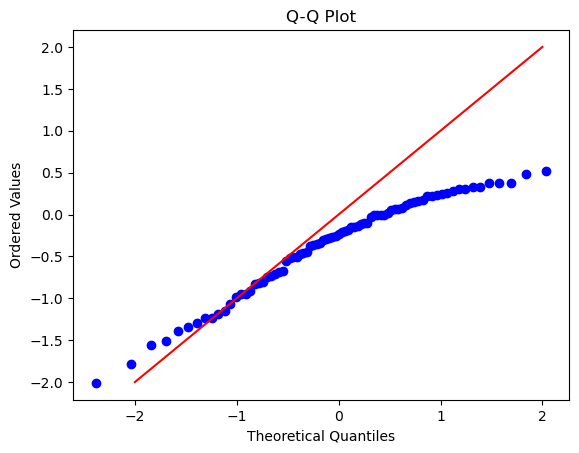

ShapiroResult(statistic=0.9439313411712646, pvalue=0.001573858316987753)

In [167]:
stats.probplot(dfSES["ses_all_mean"], dist="norm", plot=plt)
ax = plt.gca()
xlim = [-2, 2]
ylim = [-2, 2]
ax.plot(xlim, ylim, color = "red", linestyle="-", clip_on=True, scalex=False, scaley=False)
plt.title('Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

data1 = dfSES["ses_all_mean"]
data_no_nan1 = data1[~np.isnan(data1)]
stats.shapiro(data_no_nan1)

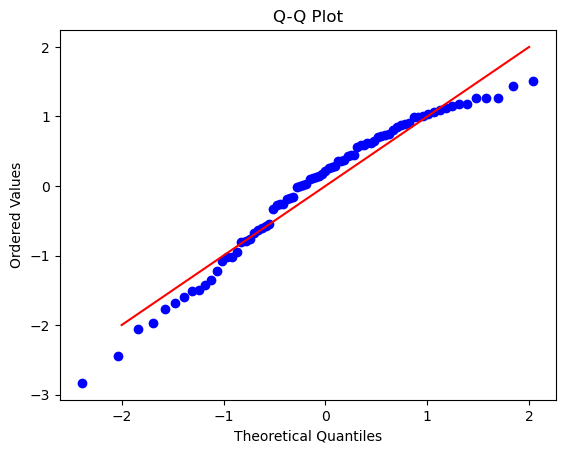

ShapiroResult(statistic=0.9439312219619751, pvalue=0.001573833986185491)

In [169]:
stats.probplot(dfSES["normalized_ses_all_mean"], dist="norm", plot=plt)
ax = plt.gca()
xlim = [-2, 2]
ylim = [-2, 2]
ax.plot(xlim, ylim, color = "red", linestyle="-", clip_on=True, scalex=False, scaley=False)
plt.title('Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

data2 = dfSES["normalized_ses_all_mean"]
data_no_nan2 = data2[~np.isnan(data2)]
stats.shapiro(data_no_nan2)

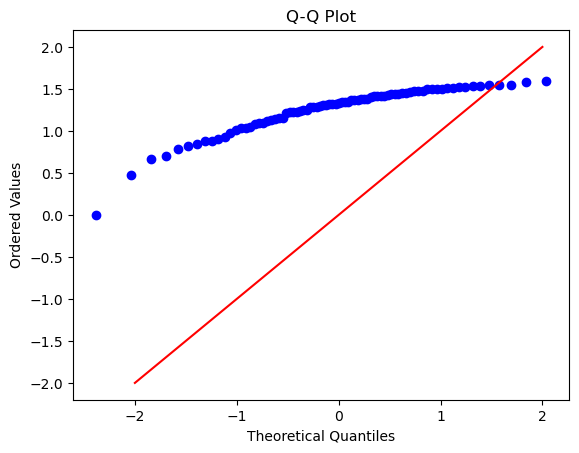

ShapiroResult(statistic=0.8563417792320251, pvalue=2.6593207280711795e-07)

In [175]:
stats.probplot(dfSES["shift_and_log"], dist="norm", plot=plt)
ax = plt.gca()
xlim = [-2, 2]
ylim = [-2, 2]
ax.plot(xlim, ylim, color = "red", linestyle="-", clip_on=True, scalex=False, scaley=False)
plt.title('Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

data3 = dfSES["shift_and_log"]
data_no_nan3 = data3[~np.isnan(data3)]
stats.shapiro(data_no_nan3)

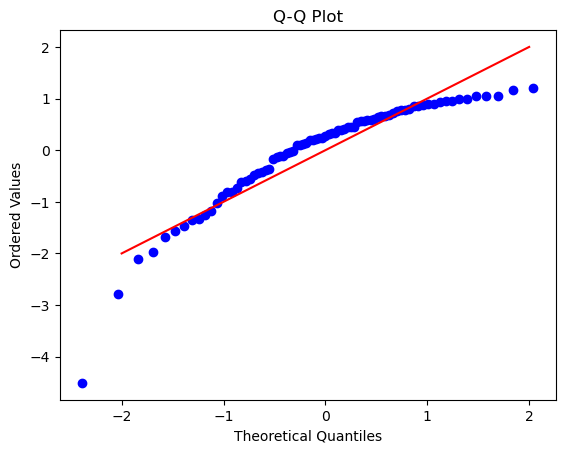

ShapiroResult(statistic=0.8563417792320251, pvalue=2.6593207280711795e-07)

In [179]:
stats.probplot(dfSES["normalize_shift_log"], dist="norm", plot=plt)
ax = plt.gca()
xlim = [-2, 2]
ylim = [-2, 2]
ax.plot(xlim, ylim, color = "red", linestyle="-", clip_on=True, scalex=False, scaley=False)
plt.title('Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

data4 = dfSES["normalize_shift_log"]
data_no_nan4 = data4[~np.isnan(data4)]
stats.shapiro(data_no_nan4)

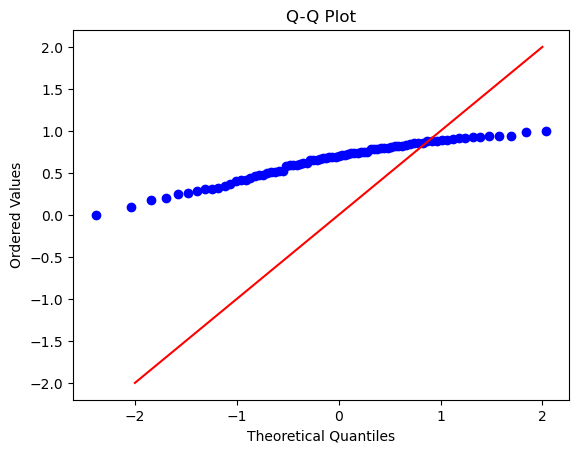

ShapiroResult(statistic=0.9439313411712646, pvalue=0.001573858316987753)

In [181]:
stats.probplot(dfSES["min_max_scaled"], dist="norm", plot=plt)
ax = plt.gca()
xlim = [-2, 2]
ylim = [-2, 2]
ax.plot(xlim, ylim, color = "red", linestyle="-", clip_on=True, scalex=False, scaley=False)
plt.title('Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

data5 = dfSES["min_max_scaled"]
data_no_nan5 = data5[~np.isnan(data5)]
stats.shapiro(data_no_nan5)

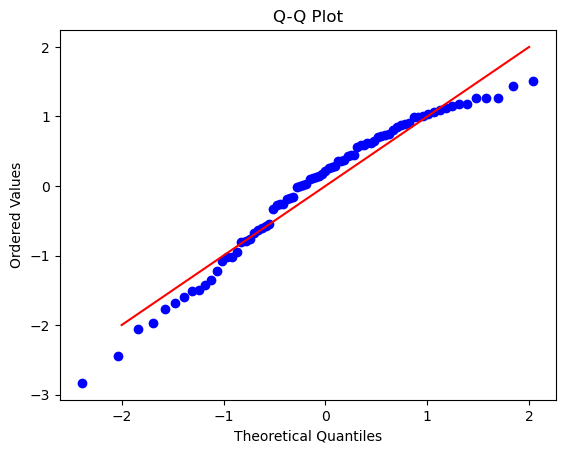

ShapiroResult(statistic=0.9439312219619751, pvalue=0.001573833986185491)

In [185]:
stats.probplot(dfSES["scaled_and_normalized"], dist="norm", plot=plt)
ax = plt.gca()
xlim = [-2, 2]
ylim = [-2, 2]
ax.plot(xlim, ylim, color = "red", linestyle="-", clip_on=True, scalex=False, scaley=False)
plt.title('Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

data6 = dfSES["scaled_and_normalized"]
data_no_nan6 = data6[~np.isnan(data6)]
stats.shapiro(data_no_nan6)